OpenPNM testing tutorials from https://openpnm.org/examples/tutorial

In [1]:
import openpnm as op
import numpy as np
import matplotlib.pyplot as plt
op.visualization.set_mpl_style()

Regular network!

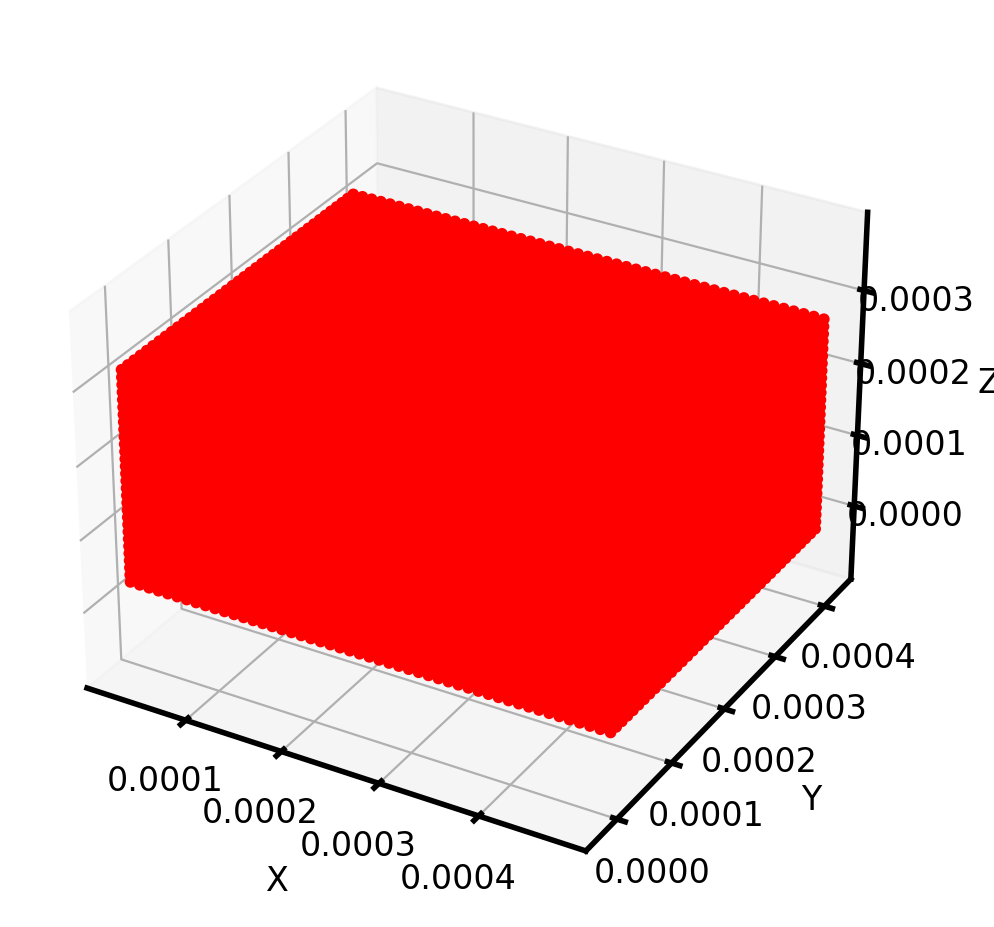

In [2]:
# This is a very very basic cubic network that has no properties other than geometry
#pn = op.network.Cubic(shape=[5, 4, 3], spacing=1)

# This is a demo cubic network equipped with some basic properties
np.random.seed(0)
pn = op.network.Demo(shape=[50,40,30],spacing=1e-5) # I am assuming scaling as a distance btw two pores on cubic net

# Basic plot
ax = op.visualization.plot_coordinates(pn)
ax = op.visualization.plot_connections(pn, ax=ax)

In [3]:
print('\nNumber of pores:',pn.Np)
print('\nNumber of throats:',pn.Nt)

print(pn)


Number of pores: 60000

Number of throats: 175300

══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Demo at 0x1c875961a40>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.coords                                                 60000 / 60000
  3  throat.conns                                              175300 / 175300
  4  pore.coordination_number                                    60000 / 60000
  5  pore.max_size                                               60000 / 60000
  6  throat.spacing                                            175300 / 175300
  7  pore.seed                                                   60000 / 60000
  8  pore.diameter                                               60000 / 60000
  9  throat.max_size             

In [ ]:
# The above names are dictionary keys for pore network properties, and currently there are only two. Here is how we access/print one of them.
print(pn['pore.coords'])

In [24]:

# spreadsheet analogies for pore data, this loads all properties with one dimension into a data frame
# Note that the properties with 3 dimensions such as coordinates do not work well with this
import pandas as pd
pore_data_sheet = pd.DataFrame({k: pn[k] for k in pn.props(element='pore') if pn[k].ndim == 1})
pore_data_sheet

,pore.coordination_number,pore.diameter,pore.max_size,pore.seed,pore.volume
0,3.0,0.000005,0.00001,0.474407,5.590507e-17
1,4.0,0.000006,0.00001,0.557595,9.077254e-17
2,4.0,0.000005,0.00001,0.501382,6.599394e-17
3,4.0,0.000005,0.00001,0.472442,5.521321e-17
4,4.0,0.000004,0.00001,0.411827,3.657163e-17
...,...,...,...,...,...
59995,4.0,0.000006,0.00001,0.641624,1.383055e-16
59996,4.0,0.000004,0.00001,0.390041,3.106906e-17
59997,4.0,0.000003,0.00001,0.284502,1.205743e-17
59998,4.0,0.000003,0.00001,0.331965,1.915476e-17


All properties above are numpy arrays so math can be properly done. More information: https://openpnm.org/examples/tutorials/03_data_and_topology_storage.html

Labels, however, are boolean arrays that are True only at some locations, and not others, and are used for instance to labeling volume boundaries.
Example:

In [4]:

P_left = pn.pores('left')
P_back = pn.pores('back')
#print(P_left)
#print(P_back)


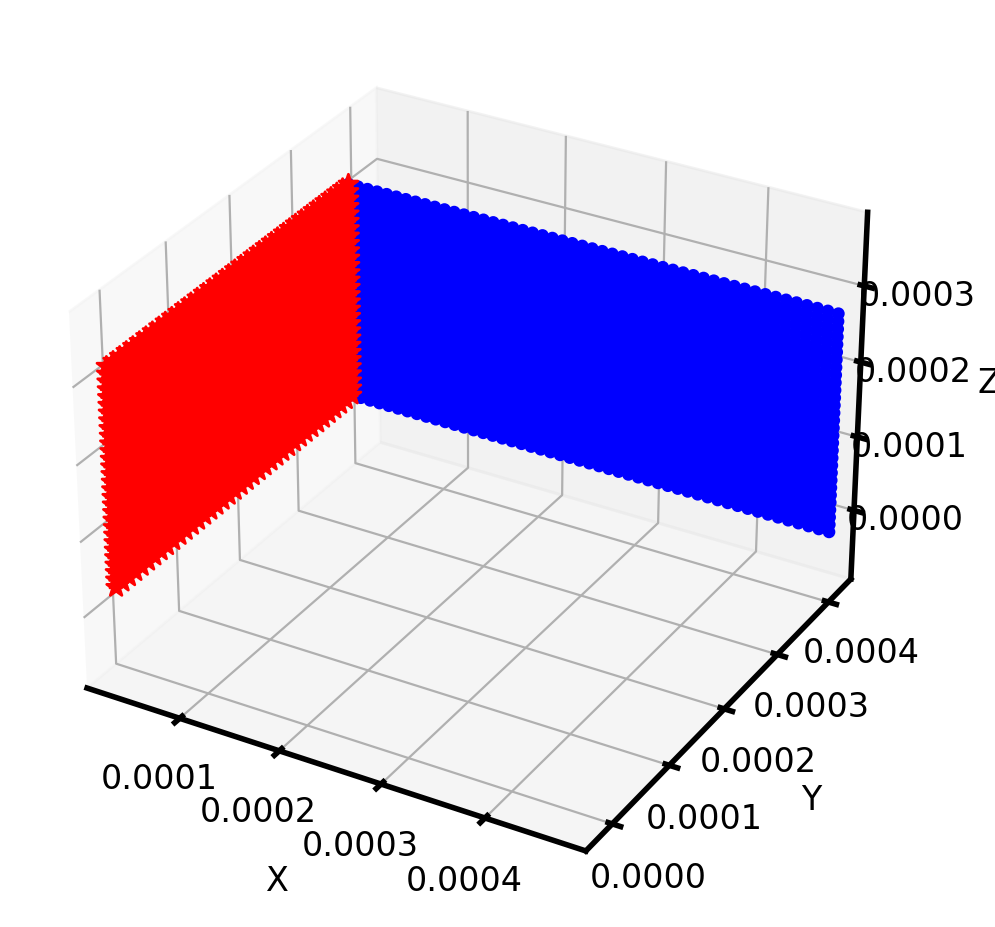

In [5]:
fig, ax = plt.subplots()

op.visualization.plot_coordinates(pn, P_left, c='red', marker='*', 
                                  markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, P_back, c='blue', marker='.', 
                                  markersize=50, ax=ax);


[  19   21 1080]
[   18    19 91600]
[2.15369841e-06 1.29568606e-06 1.29653880e-06]
Mean throat diameter of attached throats: 1.5819744220730244e-06
Aspect ratio: 3.7311892019704276


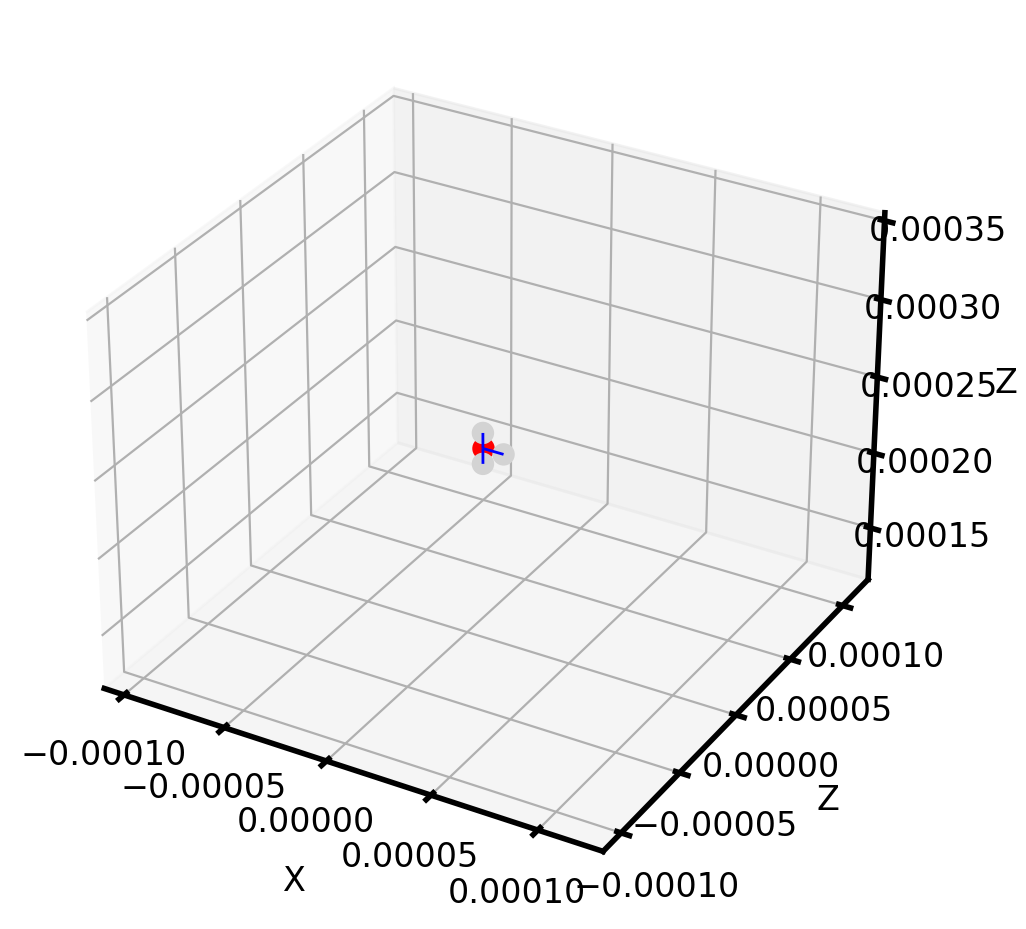

In [44]:
poreid=20  # Note that ids start from 0, just like it is in Python
# Find and plot neighboring pores for poreid
Ps = pn.find_neighbor_pores(pores=[poreid])
print(Ps)
fig, ax = plt.subplots()

op.visualization.plot_coordinates(pn, [poreid], c='red',markersize=50, ax=ax)
op.visualization.plot_coordinates(pn, Ps, c='lightgrey',markersize=50, ax=ax)

# Find and plot neighboring throats for poreid
Ts = pn.find_neighbor_throats(pores=[poreid])
print(Ts)
op.visualization.plot_connections(pn, Ts, ax=ax)

#Related throat diameters
td = pn['throat.diameter']
print(td[Ts])
temp = td[Ts]
print('Mean throat diameter of attached throats:',temp.mean())
pd = pn['pore.diameter']
print('Aspect ratio:',pd[poreid]/temp.mean())


More information about network manipulation, including how to trim pores and throats can be found on: https://openpnm.org/examples/tutorials/04_graph_queries_and_manipulation.html

(array([204152.62531908, 203219.20377942, 198285.40421259, 195751.83146206,
        200385.60267685, 204886.0279574 , 197018.61783733, 199018.8068509 ,
        199418.84465362, 198052.04882768]),
 array([2.00036225e-06, 2.50031500e-06, 3.00026775e-06, 3.50022050e-06,
        4.00017325e-06, 4.50012600e-06, 5.00007875e-06, 5.50003151e-06,
        5.99998426e-06, 6.49993701e-06, 6.99988976e-06]),
 <BarContainer object of 10 artists>)

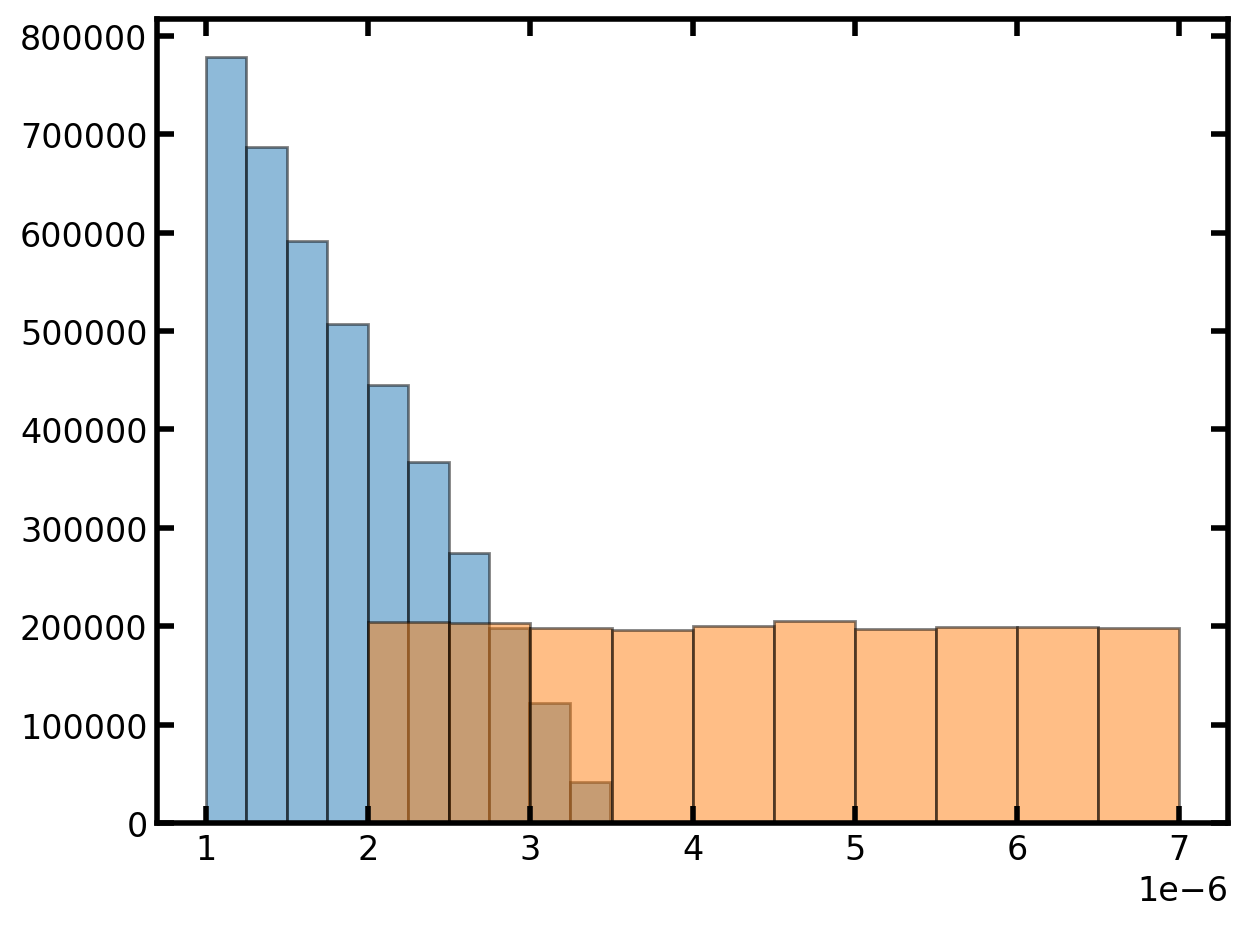

In [7]:
plt.hist(pn['throat.diameter'], edgecolor='k', density=True, alpha=0.5)
plt.hist(pn['pore.diameter'], edgecolor='k', density=True, alpha=0.5)

There are predefined modes for geometry: https://openpnm.org/examples/tutorials/05_defining_geometry.html#using-predefined-collections-of-models

In [ ]:
# This simple demo network is prequipped with sphere and cylinder model.
print(pn.models)

# We can also add a model to a network that does not have one:
#pn.add_model_collection(op.models.collections.geometry.spheres_and_cylinders)
#pn.regenerate_models()

## Adding phases and fluids, computing transport properties

Phases:
https://openpnm.org/examples/tutorials/07_phases_and_mixtures.html

Single phase transport:
https://openpnm.org/examples/tutorials/08_simulating_transport.html


In [8]:
water = op.phase.Phase(network=pn)

#water.add_model(propname='pore.viscosity',model=op.models.phase.viscosity.water_correlation)
#print(water)

water['pore.viscosity']= 1 #not using actual values. as we are going to divide by it when calculating permeability
water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()  #I think this populates throat viscosity by interpolating neighboring pores
#print(water)


[10:54:53] WARNING  throat.entry_pressure was not run since the following property is missing:       ]8;id=740495;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=827038;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    'throat.surface_tension'                                                                       

           WARNING  throat.diffusive_conductance was not run since the following property is         ]8;id=680453;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=491061;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\core\_models.py#480\480]8;;\
                    missing: 'throat.diffusivity'                                                                  

In [ ]:
print(water['pore.viscosity'])
print(water['throat.viscosity'])

In [9]:
# Calculate throat conductance based on the Hagen Poiseulle model for a cylinder
R = pn['throat.diameter']/2.0 # cylinder radius
L = pn['throat.length']       #cylinder length
mu = water['throat.viscosity']  
water['throat.hydraulic_conductance'] = np.pi*R**4/(8*mu*L)
print(water['throat.hydraulic_conductance'])

[1.43289086e-19 1.81577878e-19 1.33067349e-19 ... 7.80549300e-21
 2.83266579e-20 4.00622225e-20]


In [10]:
# Pressure driven low Reynolds number flow algorithm
flow = op.algorithms.StokesFlow(network=pn, phase=water)
print(flow)

#'left' and 'right' are x direction volume boundaries
inlet = pn.pores('left')
outlet = pn.pores('right')

# Assign bounday conditions to left and right boundaries
#To calculate permeability in x direction, a constant pressure boundary condition is applied on the left and right side of the network.
flow.set_value_BC(inlet, values=1)  
flow.set_value_BC(outlet, values=0)
print(flow)


# Run
soln = flow.run()
water.update(flow.soln)



══════════════════════════════════════════════════════════════════════════════
stokes_01 : <openpnm.algorithms.StokesFlow at 0x213ce937ac0>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.bc.rate                                                    0 / 60000
  3  pore.bc.value                                                   0 / 60000
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Labels                                                 Assigned Locations
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.all                                                            60000
  3  throat.all                                                         175300
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

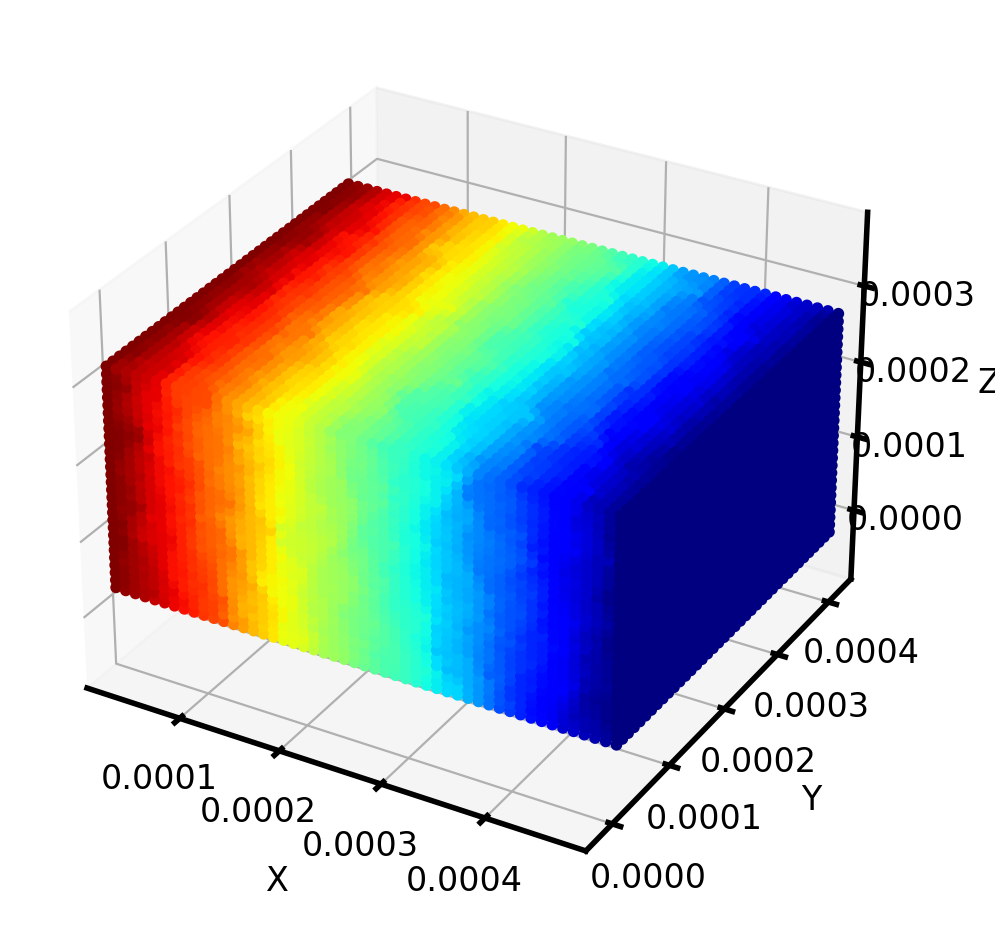

In [11]:
ax = op.visualization.plot_connections(pn)
ax = op.visualization.plot_coordinates(pn, ax=ax,color_by=water['pore.pressure'])

In [12]:
Q = flow.rate(pores=inlet, mode='group')[0]
A = op.topotools.get_domain_area(pn, inlets=inlet, outlets=outlet)
L = op.topotools.get_domain_length(pn, inlets=inlet, outlets=outlet)
# K = Q * L * mu / (A * Delta_P) # mu and Delta_P were assumed to be 1.
K = Q * L / A

# CONVERSION ASSUMES THAT 'scaling' network values are in microns
print(f'The value of K is: {K/0.98e-12*1000:.2f} mD') 

[10:55:56] WARNING  Attempting to estimate inlet area...will be low                              ]8;id=505472;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=57431;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1046\1046]8;;\

           WARNING  Attempting to estimate domain length...could be low if boundary pores were   ]8;id=368447;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=895535;file://C:\Users\masha\miniconda3\Lib\site-packages\openpnm\topotools\_topotools.py#1090\1090]8;;\
                    not added                                                                                      

The value of K is: 7.09 mD


## Exercises
1. Cement model #1: Manipulate throat diameters to have all throats reduced by 75% and see how that affects permeability.
2. Cement model #2: Take a fixed cement value and imagine uniform layer of cement in all throats. Manipulate throat diameters to dedcut cement
   value from them and then recompute permeability. Some throats might close as a result and need to get trimmed.
3. Compute aspect ratio (average neighboring throat diameters divided by pore diameter) for every pore and histogram the result.

In [34]:
# Cement model 2.

# diameters of throats
td = pn['throat.diameter']

# cement value scales with minimum diameter
cement = 1.05*td.min()

#cement some of the throats
td = td - cement

#trim throats whose diamaters are <=0
throat_ids = np.arange(0,pn.Nt)
#print(ids)
throats_for_removal = throat_ids[td <= 0]

#print(throats_for_removal)

op.topotools.trim(network=pn,throats = throats_for_removal)

# Some pores must have disconnected...
h = op.utils.check_network_health(pn)
print(h)

# Remove disconnected pores
op.topotools.trim(network=pn, pores=h['disconnected_pores'])



――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      [14, 49, 57, 63, 65, 81, 137, 241, 273, 286, 367, 412, 466, 482, 502, 506, 559, 581, 593, 620, 625, 630, 642, 714, 718, 767, 835, 853, 912, 925, 980, 998, 1024, 1040, 1044, 1057, 1063, 1105, 1126, 1173, 1187, 1195, 1266, 1296, 1306, 1320, 1399, 1456, 1469, 1496, 1525, 1551, 1583, 1587, 1597, 1671, 1723, 1762, 1946, 2009, 2113, 2137, 2168, 2227, 2237, 2261, 2345, 2368, 2370, 2381, 2393, 2508, 2524, 2525, 2557, 2561, 2582, 2618, 2665, 2708, 2726, 2814, 2899, 2922, 3004, 3022, 3059, 3072, 3089, 3103, 3109, 3111, 3236, 3238, 3243, 3264, 3280, 3314, 3324, 3327, 3340, 3356, 3379, 3386, 3413, 3516, 3586, 3605, 3636, 3645, 3735, 3754, 3776, 3805, 3890, 3936, 4011, 4039, 4047, 4051, 422

In [4]:
print('\nFinal check that network topology is ready for simulation')
h = op.utils.check_network_health(pn)
print(h)


Final check that network topology is ready for simulation
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


In [5]:
#Redo calculation

water = op.phase.Phase(network=pn)
water['pore.viscosity']= 1 #not using actual values. as we are going to divide by it when calculating permeability
water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()  #I think this populates throat viscosity by interpolating neighboring pores

# Calculate throat conductance based on the Hagen Poiseulle model for a cylinder
R = pn['throat.diameter']/2.0 # cylinder radius
L = pn['throat.length']       #cylinder length
mu = water['throat.viscosity']  
water['throat.hydraulic_conductance'] = np.pi*R**4/(8*mu*L)
print(water['throat.hydraulic_conductance'])

# Pressure driven low Reynolds number flow algorithm
flow = op.algorithms.StokesFlow(network=pn, phase=water)
print(flow)

#'left' and 'right' are x direction volume boundaries
inlet = pn.pores('left')
outlet = pn.pores('right')

# Assign bounday conditions to left and right boundaries
#To calculate permeability in x direction, a constant pressure boundary condition is applied on the left and right side of the network.
flow.set_value_BC(inlet, values=1)  
flow.set_value_BC(outlet, values=0)
print(flow)


# Run
soln = flow.run()
water.update(flow.soln)

# Compare to Darcy's law
Q = flow.rate(pores=inlet, mode='group')[0]
A = op.topotools.get_domain_area(pn, inlets=inlet, outlets=outlet)
L = op.topotools.get_domain_length(pn, inlets=inlet, outlets=outlet)
# K = Q * L * mu / (A * Delta_P) # mu and Delta_P were assumed to be 1.
K = Q * L / A
print(f'The value of K is: {K/0.98e-12*1000:.2f} mD')

[13:46:41] WARNING  throat.entry_pressure was not run since the following property is missing:       ]8;id=77297;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=941942;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\core\_models.py#480\480]8;;\
                    'throat.surface_tension'                                                                       

           WARNING  throat.diffusive_conductance was not run since the following property is         ]8;id=682801;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\core\_models.py\_models.py]8;;\:]8;id=786120;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\core\_models.py#480\480]8;;\
                    missing: 'throat.diffusivity'                                                                  

[1.43289086e-19 1.81577878e-19 1.33067349e-19 ... 7.80549300e-21
 2.83266579e-20 4.00622225e-20]

══════════════════════════════════════════════════════════════════════════════
stokes_01 : <openpnm.algorithms.StokesFlow at 0x1c80540acb0>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.bc.rate                                                    0 / 60000
  3  pore.bc.value                                                   0 / 60000
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Labels                                                 Assigned Locations
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.all                                                            60000
  3  throat.all                                    

[13:46:44] WARNING  Attempting to estimate inlet area...will be low                              ]8;id=151095;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=532595;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\topotools\_topotools.py#1046\1046]8;;\

           WARNING  Attempting to estimate domain length...could be low if boundary pores were   ]8;id=219068;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\topotools\_topotools.py\_topotools.py]8;;\:]8;id=104074;file://C:\Users\masha\AppData\Roaming\Python\Python312\site-packages\openpnm\topotools\_topotools.py#1090\1090]8;;\
                    not added                                                                                      

The value of K is: 7.09 mD
